In [1]:
pip install flask==3.0.2 flask-sqlalchemy==3.1.1 flask-login==0.6.3 werkzeug==3.0.1 torch==2.2.1 transformers==4.38.2 numpy==1.26.4 python-dotenv==1.0.1 gunicorn==21.2.0

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from collections import deque
import random
import os
from transformers import AutoTokenizer, AutoModel
import torch.nn.functional as F
import time
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datetime import datetime
import json

class TextEncoder(nn.Module):
    def __init__(self, model_name='bert-base-uncased'):
        super(TextEncoder, self).__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        
    def encode_text(self, text):
        # Tokenize and encode text
        inputs = self.tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512)
        with torch.no_grad():
            outputs = self.bert(**inputs)
        # Use [CLS] token embedding as text representation
        return outputs.last_hidden_state[:, 0, :]

class ChargesheetEnvironment:
    def __init__(self):
        # Define IPC sections with their categories and relationships
        self.section_categories = {
            "offenses_against_state": {
                "sections": ["IPC 121", "IPC 124A", "IPC 125", "IPC 131", "IPC 121A", "IPC 122", "IPC 123", "IPC 126", "IPC 127", "IPC 128", "IPC 129", "IPC 130"],
                "description": "Offenses against the State including waging war, sedition, and anti-national activities",
                "related_categories": ["public_tranquility", "criminal_conspiracy"]
            },
            "public_justice": {
                "sections": ["IPC 191", "IPC 193", "IPC 196", "IPC 211", "IPC 192", "IPC 194", "IPC 195", "IPC 197", "IPC 198", "IPC 199", "IPC 200", "IPC 201", "IPC 202", "IPC 203", "IPC 204", "IPC 205", "IPC 206", "IPC 207", "IPC 208", "IPC 209", "IPC 210", "IPC 212", "IPC 213", "IPC 214", "IPC 215", "IPC 216", "IPC 216A", "IPC 217", "IPC 218", "IPC 219", "IPC 220", "IPC 221", "IPC 222", "IPC 223", "IPC 224", "IPC 225", "IPC 225A", "IPC 225B", "IPC 226"],
                "description": "Offenses against public justice including false evidence, charges, and obstruction of justice",
                "related_categories": ["public_servants", "fraud"]
            },
            "public_tranquility": {
                "sections": ["IPC 141", "IPC 143", "IPC 146", "IPC 147", "IPC 153A", "IPC 153B", "IPC 142", "IPC 144", "IPC 145", "IPC 148", "IPC 149", "IPC 150", "IPC 151", "IPC 152", "IPC 153", "IPC 154", "IPC 155", "IPC 156", "IPC 157", "IPC 158", "IPC 159", "IPC 160", "IPC 161", "IPC 162", "IPC 163", "IPC 164", "IPC 165"],
                "description": "Offenses against public tranquility including unlawful assembly, rioting, and promoting enmity",
                "related_categories": ["offenses_against_state", "public_justice", "criminal_intimidation"]
            },
            "public_servants": {
                "sections": ["IPC 166", "IPC 167", "IPC 168", "IPC 171E", "IPC 169", "IPC 170", "IPC 171", "IPC 171A", "IPC 171B", "IPC 171C", "IPC 171D", "IPC 171F", "IPC 171G", "IPC 171H", "IPC 171I"],
                "description": "Offenses by public servants including disobedience, bribery, and electoral offenses",
                "related_categories": ["public_justice", "fraud", "criminal_conspiracy"]
            },
            "offenses_against_life": {
                "sections": ["IPC 299", "IPC 300", "IPC 302", "IPC 304", "IPC 304A", "IPC 304B", "IPC 306", "IPC 307", "IPC 308", "IPC 309", "IPC 301", "IPC 303", "IPC 305", "IPC 310", "IPC 311", "IPC 312", "IPC 313", "IPC 314", "IPC 315", "IPC 316", "IPC 317", "IPC 318"],
                "description": "Offenses against life including murder, culpable homicide, and related offenses",
                "related_categories": ["hurt_grievous_hurt", "crimes_against_women", "criminal_intimidation"]
            },
            "hurt_grievous_hurt": {
                "sections": ["IPC 319", "IPC 320", "IPC 321", "IPC 322", "IPC 323", "IPC 324", "IPC 325", "IPC 326", "IPC 326A", "IPC 327", "IPC 328", "IPC 329", "IPC 330", "IPC 331", "IPC 332", "IPC 333", "IPC 334", "IPC 335", "IPC 336", "IPC 337", "IPC 338"],
                "description": "Hurt and grievous hurt offenses including assault, acid attacks, and dangerous weapon injuries",
                "related_categories": ["offenses_against_life", "crimes_against_women", "criminal_intimidation"]
            },
            "wrongful_restraint": {
                "sections": ["IPC 339", "IPC 340", "IPC 341", "IPC 342", "IPC 343", "IPC 344", "IPC 345", "IPC 346", "IPC 347", "IPC 348", "IPC 349", "IPC 350", "IPC 351", "IPC 352", "IPC 353", "IPC 354", "IPC 355", "IPC 356", "IPC 357", "IPC 358"],
                "description": "Wrongful restraint, confinement, and related offenses against personal liberty",
                "related_categories": ["kidnapping", "crimes_against_women", "criminal_intimidation"]
            },
            "crimes_against_women": {
                "sections": ["IPC 354", "IPC 354A", "IPC 354B", "IPC 354C", "IPC 354D", "IPC 375", "IPC 376", "IPC 376A", "IPC 376B", "IPC 376C", "IPC 376D", "IPC 376E", "IPC 498A", "IPC 498B", "IPC 498C", "IPC 498D", "IPC 498E"],
                "description": "Offenses against women including assault, harassment, domestic violence, and sexual offenses",
                "related_categories": ["kidnapping", "hurt_grievous_hurt", "offenses_against_life", "criminal_intimidation"]
            },
            "kidnapping": {
                "sections": ["IPC 359", "IPC 360", "IPC 361", "IPC 362", "IPC 363A", "IPC 366A", "IPC 366B", "IPC 363", "IPC 364", "IPC 364A", "IPC 365", "IPC 366", "IPC 367", "IPC 368", "IPC 368A", "IPC 369", "IPC 370", "IPC 370A", "IPC 371", "IPC 372", "IPC 373", "IPC 374", "IPC 375", "IPC 376", "IPC 376A", "IPC 376B", "IPC 376C", "IPC 376D", "IPC 376E"],
                "description": "Kidnapping, abduction, human trafficking, and related offenses",
                "related_categories": ["crimes_against_women", "wrongful_restraint", "criminal_intimidation"]
            },
            "property_offenses": {
                "sections": ["IPC 378", "IPC 379", "IPC 380", "IPC 381", "IPC 382", "IPC 384", "IPC 386", "IPC 390", "IPC 392", "IPC 395", "IPC 396", "IPC 399", "IPC 402", "IPC 403", "IPC 405", "IPC 406", "IPC 409", "IPC 383", "IPC 385", "IPC 387", "IPC 388", "IPC 389", "IPC 391", "IPC 393", "IPC 394", "IPC 397", "IPC 398", "IPC 400", "IPC 401", "IPC 404", "IPC 407", "IPC 408", "IPC 410", "IPC 411", "IPC 412", "IPC 413", "IPC 414", "IPC 451", "IPC 452", "IPC 453"],
                "description": "Theft, robbery, dacoity, and property-related crimes",
                "related_categories": ["fraud", "criminal_intimidation", "criminal_conspiracy"]
            },
            "fraud": {
                "sections": ["IPC 415", "IPC 417", "IPC 418", "IPC 420", "IPC 463", "IPC 465", "IPC 467", "IPC 468", "IPC 471", "IPC 477A", "IPC 416", "IPC 419", "IPC 421", "IPC 422", "IPC 423", "IPC 424", "IPC 425", "IPC 426", "IPC 427", "IPC 428", "IPC 429", "IPC 430", "IPC 431", "IPC 432", "IPC 433", "IPC 434", "IPC 435", "IPC 436", "IPC 437", "IPC 438", "IPC 439", "IPC 440", "IPC 441", "IPC 442", "IPC 443", "IPC 444", "IPC 445", "IPC 446", "IPC 447", "IPC 448", "IPC 449", "IPC 450", "IPC 451", "IPC 452", "IPC 453", "IPC 454", "IPC 455", "IPC 456", "IPC 457", "IPC 458", "IPC 459", "IPC 460", "IPC 461", "IPC 462", "IPC 464", "IPC 466", "IPC 469", "IPC 470", "IPC 472", "IPC 473", "IPC 474", "IPC 475", "IPC 476", "IPC 477", "IPC 478", "IPC 479", "IPC 480", "IPC 481", "IPC 482", "IPC 483", "IPC 484", "IPC 485", "IPC 486", "IPC 487", "IPC 488", "IPC 489", "IPC 489A", "IPC 489B", "IPC 489C", "IPC 489E"],
                "description": "Cheating, forgery, counterfeiting, and fraud-related offenses",
                "related_categories": ["property_offenses", "public_servants", "criminal_conspiracy"]
            },
            "criminal_intimidation": {
                "sections": ["IPC 503", "IPC 504", "IPC 505", "IPC 506", "IPC 507", "IPC 509", "IPC 500", "IPC 501", "IPC 502", "IPC 508", "IPC 510", "IPC 511"],
                "description": "Criminal intimidation, defamation, and insult-related offenses",
                "related_categories": ["property_offenses", "crimes_against_women", "public_tranquility"]
            },
            "criminal_conspiracy": {
                "sections": ["IPC 120A", "IPC 120B"],
                "description": "Criminal conspiracy and abetment-related offenses",
                "related_categories": ["property_offenses", "offenses_against_state", "public_justice"]
            }
        }
        
        # Create a mapping of sections to their categories
        self.section_to_category = {}
        for category, info in self.section_categories.items():
            for section in info["sections"]:
                self.section_to_category[section] = category
        
        # Flatten sections list while preserving category information
        self.sections = []
        for category_info in self.section_categories.values():
            self.sections.extend(category_info["sections"])
        
        self.max_sections = 7
        self.current_sections = []
        self.current_categories = set()
        
        # Calculate state size once during initialization
        self.state_size = len(self.sections) + len(self.section_categories)
        print(f"Environment initialized with state size: {self.state_size}")
        
        # Add model directory
        self.model_dir = "models"
        if not os.path.exists(self.model_dir):
            os.makedirs(self.model_dir)
        
        # Add descriptions for each IPC section
        self.section_descriptions = {
            # Offenses against State
            "IPC 121": "Waging war against Government of India, armed rebellion, treason, anti-national activities, insurgency, armed uprising, state terrorism",
            "IPC 121A": "Conspiracy to commit offenses against state, plotting against government, anti-national planning, seditious conspiracy",
            "IPC 122": "Collecting arms with intention of waging war, weapon stockpiling, military preparation, armed rebellion planning",
            "IPC 123": "Concealing with intent to facilitate design to wage war, hiding weapons, supporting rebellion, aiding insurgency",
            "IPC 124A": "Sedition - Bringing hatred or contempt towards government, anti-government activities, inciting violence against state, revolutionary activities, anti-national speech",
            "IPC 125": "Waging war against friendly state, attacking foreign diplomats, international terrorism, cross-border aggression",
            "IPC 126": "Depredation on territories of friendly state, cross-border raids, international aggression, foreign territory attack",
            "IPC 127": "Receiving property taken by war or depredation, handling war loot, stolen property from conflict",
            "IPC 128": "Public servant voluntarily allowing prisoner to escape, jailbreak facilitation, prisoner release, escape aid",
            "IPC 129": "Public servant negligently suffering prisoner to escape, careless prisoner supervision, escape due to negligence",
            "IPC 130": "Aiding escape of, rescuing or harboring prisoner, helping escaped convicts, hiding fugitives, escape assistance",
            "IPC 131": "Abetting mutiny, inciting armed forces to rebel, military insubordination, defense force rebellion",

            # Public Justice
            "IPC 191": "Giving false evidence, perjury, lying under oath, false testimony in court, judicial deception, court fraud",
            "IPC 192": "Fabricating false evidence, creating fake proof, evidence tampering, document falsification",
            "IPC 193": "Punishment for false evidence, perjury consequences, false testimony penalties, court deception punishment",
            "IPC 194": "Giving or fabricating false evidence with intent to procure conviction of capital offense, death penalty fraud, serious crime frame-up",
            "IPC 195": "Giving or fabricating false evidence with intent to procure conviction of offense punishable with imprisonment, jail term fraud, imprisonment frame-up",
            "IPC 196": "Using evidence known to be false, submitting forged documents, fake evidence in court, evidence fraud",
            "IPC 197": "Issuing or signing false certificate, document forgery, fake certification, false documentation",
            "IPC 198": "Using as true a certificate known to be false, using fake documents, forged certification usage",
            "IPC 199": "False statement made in declaration which is by law receivable as evidence, false declaration, fake statement",
            "IPC 200": "Using as true such declaration knowing it to be false, using fake declarations, false statement usage",
            "IPC 201": "Causing disappearance of evidence of offense, evidence destruction, proof hiding, crime cover-up",
            "IPC 202": "Intentional omission to give information of offense by person bound to inform, failure to report crime, information suppression",
            "IPC 203": "Giving false information respecting an offense committed, false crime reporting, misleading information",
            "IPC 204": "Destruction of document to prevent its production as evidence, evidence destruction, document hiding",
            "IPC 205": "False personation for purpose of act or proceeding in suit or prosecution, identity fraud, fake representation",
            "IPC 206": "Fraudulent removal or concealment of property to prevent its seizure as forfeited, property hiding, asset concealment",
            "IPC 207": "Fraudulent claim to property to prevent its seizure as forfeited, false property claim, asset fraud",
            "IPC 208": "Fraudulently suffering decree for sum not due, fake court order, false judgment claim",
            "IPC 209": "Dishonestly making false claim in Court, court fraud, false legal claim",
            "IPC 210": "Fraudulently obtaining decree for sum not due, fake court order, false judgment fraud",
            "IPC 211": "False charge of offence, malicious prosecution, false accusation, fake complaint, wrongful allegation",
            "IPC 212": "Harboring offender, hiding criminals, sheltering fugitives, escape assistance",
            "IPC 213": "Taking gift to screen offender from punishment, bribe for protection, escape facilitation payment",
            "IPC 214": "Offering gift or restoration of property in consideration of screening offender, bribe for protection, escape payment",
            "IPC 215": "Taking gift to help to recover stolen property, bribe for recovery, stolen goods payment",
            "IPC 216": "Harboring offender who has escaped from custody, hiding escaped convicts, fugitive shelter",
            "IPC 216A": "Penalty for harboring robbers or dacoits, hiding criminals, gang shelter",
            "IPC 217": "Public servant disobeying direction of law with intent to save person from punishment, official misconduct, law violation",
            "IPC 218": "Public servant framing incorrect record or writing with intent to save person from punishment, official document fraud",
            "IPC 219": "Public servant in judicial proceeding corruptly making report, etc., contrary to law, judicial corruption",
            "IPC 220": "Commitment for trial or confinement by person having authority who knows that he is acting contrary to law, illegal detention",
            "IPC 221": "Intentional omission to apprehend on the part of public servant bound to apprehend, failure to arrest",
            "IPC 222": "Intentional omission to apprehend on the part of public servant bound to apprehend person under sentence, failure to arrest convict",
            "IPC 223": "Escape from confinement or custody negligently suffered by public servant, prisoner escape due to negligence",
            "IPC 224": "Resistance or obstruction by a person to his lawful apprehension, escape attempt, arrest resistance",
            "IPC 225": "Resistance or obstruction to lawful apprehension of another person, helping escape, arrest prevention",
            "IPC 225A": "Omission to apprehend, or sufferance of escape, on part of public servant, in cases not already provided for, general escape facilitation",
            "IPC 225B": "Resistance or obstruction to lawful apprehension, or escape or rescue in cases not already provided for, general escape assistance",
            "IPC 226": "Unlawful return from transportation, illegal return from exile, unauthorized return",

            # Offenses against Life
            "IPC 299": "Culpable homicide, causing death by negligence, manslaughter, unintentional killing, death by carelessness",
            "IPC 300": "Murder definition, intentional killing, premeditated homicide, first-degree murder, cold-blooded killing, planned murder",
            "IPC 301": "Culpable homicide by causing death of person other than person whose death was intended, wrong person killing, mistaken identity murder",
            "IPC 302": "Murder, intentional killing, premeditated homicide, first-degree murder, cold-blooded killing, planned murder, willful killing",
            "IPC 303": "Murder by life-convict, murder by prisoner, killing by convict, prison murder",
            "IPC 304": "Culpable homicide not amounting to murder, second-degree murder, unintentional killing with knowledge, manslaughter",
            "IPC 304A": "Causing death by negligence, accidental death, negligent homicide, careless driving death, death by recklessness",
            "IPC 304B": "Dowry death, bride burning, dowry harassment death, domestic violence murder, marriage-related killing",
            "IPC 305": "Abetment of suicide of child or insane person, causing minor's suicide, mental patient suicide",
            "IPC 306": "Abetment of suicide, causing suicide, driving to suicide, mental harassment leading to suicide, suicide instigation",
            "IPC 307": "Attempt to murder, attempted homicide, failed murder attempt, murderous assault, murder attempt",
            "IPC 308": "Attempt to commit culpable homicide, attempted manslaughter, failed killing attempt, unintentional murder attempt",
            "IPC 309": "Attempt to commit suicide, self-harm, self-injury, suicidal behavior, self-destruction attempt",
            "IPC 310": "Thug, professional killer, contract killer, hired assassin, murder for hire",
            "IPC 311": "Punishment for thug, professional killer penalty, contract killer punishment",
            "IPC 312": "Causing miscarriage, abortion, pregnancy termination, fetal death",
            "IPC 313": "Causing miscarriage without woman's consent, forced abortion, unauthorized pregnancy termination",
            "IPC 314": "Death caused by act done with intent to cause miscarriage, fatal abortion, death during pregnancy termination",
            "IPC 315": "Act done with intent to prevent child being born alive or to cause it to die after birth, infanticide, baby killing",
            "IPC 316": "Causing death of quick unborn child by act amounting to culpable homicide, killing unborn child, fetal homicide",
            "IPC 317": "Exposure and abandonment of child under twelve years by parent or person having care of it, child abandonment, minor desertion",
            "IPC 318": "Concealment of birth by secret disposal of dead body, hiding birth, corpse disposal",

            # Hurt and Grievous Hurt
            "IPC 319": "Hurt definition, physical injury, bodily harm, assault definition, physical damage",
            "IPC 320": "Grievous hurt definition, serious injury, severe bodily harm, life-threatening injury, major damage",
            "IPC 321": "Voluntarily causing hurt, intentional injury, deliberate assault, willful harm, planned injury",
            "IPC 322": "Voluntarily causing grievous hurt, intentional serious injury, deliberate severe harm, planned serious damage",
            "IPC 323": "Punishment for voluntarily causing hurt, assault penalties, injury consequences, harm punishment",
            "IPC 324": "Hurt by dangerous weapons, assault with deadly weapons, weapon attack, armed assault, weapon injury",
            "IPC 325": "Punishment for grievous hurt, serious injury penalties, severe harm consequences, major injury punishment",
            "IPC 326": "Grievous hurt by dangerous weapons, serious injury with weapons, armed serious assault, weapon serious injury",
            "IPC 326A": "Acid attack, chemical assault, acid throwing, corrosive substance attack, chemical injury",
            "IPC 327": "Hurt to extort property, assault for extortion, injury for blackmail, harm for ransom, forced injury",
            "IPC 328": "Causing hurt by means of poison, etc., with intent to commit an offence, poisoning, toxic injury",
            "IPC 329": "Voluntarily causing grievous hurt to extort property, serious injury for extortion, severe harm for ransom",
            "IPC 330": "Voluntarily causing hurt to extort confession or to compel restoration of property, torture for confession",
            "IPC 331": "Voluntarily causing grievous hurt to extort confession or to compel restoration of property, serious torture",
            "IPC 332": "Voluntarily causing hurt to deter public servant from his duty, assault on official, injury to prevent duty",
            "IPC 333": "Voluntarily causing grievous hurt to deter public servant from his duty, serious assault on official",
            "IPC 334": "Voluntarily causing hurt on provocation, provoked assault, anger-based injury",
            "IPC 335": "Voluntarily causing grievous hurt on provocation, provoked serious assault, anger-based serious injury",
            "IPC 336": "Act endangering life or personal safety of others, reckless endangerment, dangerous behavior",
            "IPC 337": "Causing hurt by act endangering life or personal safety of others, reckless injury, dangerous act harm",
            "IPC 338": "Causing grievous hurt by act endangering life or personal safety of others, reckless serious injury",

            # Property Offenses
            "IPC 378": "Theft, stealing, larceny, property theft, unauthorized taking",
            "IPC 379": "Punishment for theft, stealing penalties, larceny consequences, theft punishment",
            "IPC 380": "Theft in dwelling house, house breaking, home burglary, residential theft, house stealing",
            "IPC 381": "Theft by clerk or servant, employee theft, staff stealing, trusted person theft, insider theft",
            "IPC 382": "Theft after preparation for causing death, armed robbery, violent theft, deadly weapon theft",
            "IPC 383": "Extortion, blackmail, forced payment, threat for money, coercion for property",
            "IPC 384": "Punishment for extortion, blackmail penalties, forced payment consequences",
            "IPC 385": "Putting person in fear of injury in order to commit extortion, threat for extortion, injury threat",
            "IPC 386": "Extortion by putting a person in fear of death or grievous hurt, life-threatening extortion, serious injury threat",
            "IPC 387": "Putting person in fear of death or of grievous hurt in order to commit extortion, death threat for extortion",
            "IPC 388": "Extortion by threat of accusation of an offence punishable with death or imprisonment, blackmail with serious crime",
            "IPC 389": "Putting person in fear of accusation of offence, in order to commit extortion, threat of false accusation",
            "IPC 390": "Robbery definition, armed theft, violent stealing, force theft, property snatching",
            "IPC 391": "Dacoity, gang robbery, group theft, organized robbery, multiple person theft",
            "IPC 392": "Punishment for robbery, armed theft penalties, violent stealing consequences",
            "IPC 393": "Attempt to commit robbery, failed robbery, robbery attempt, theft attempt",
            "IPC 394": "Voluntarily causing hurt in committing robbery, injury during robbery, harm during theft",
            "IPC 395": "Punishment for dacoity, gang robbery penalties, group theft consequences",
            "IPC 396": "Dacoity with murder, gang robbery murder, group theft killing, robbery homicide",
            "IPC 397": "Robbery or dacoity, with attempt to cause death or grievous hurt, armed robbery with injury",
            "IPC 398": "Attempt to commit robbery or dacoity when armed with deadly weapon, armed robbery attempt",
            "IPC 399": "Making preparation to commit dacoity, planning gang robbery, organizing group theft",
            "IPC 400": "Punishment for belonging to gang of dacoits, gang membership penalty, organized crime group",
            "IPC 401": "Punishment for belonging to gang of thieves, theft gang membership, organized theft group",
            "IPC 402": "Assembling for purpose of committing dacoity, gang gathering, robbery planning",
            "IPC 403": "Dishonest misappropriation of property, property embezzlement, asset misappropriation",
            "IPC 404": "Dishonest misappropriation of property possessed by deceased person at the time of his death, inheritance theft",
            "IPC 405": "Criminal breach of trust, trust violation, fiduciary breach, entrusted property misuse",
            "IPC 406": "Punishment for criminal breach of trust, trust violation penalties",
            "IPC 407": "Criminal breach of trust by carrier, etc., transport theft, shipping fraud",
            "IPC 408": "Criminal breach of trust by clerk or servant, employee theft, staff embezzlement",
            "IPC 409": "Criminal breach of trust by public servant, official corruption, government trust violation",
            "IPC 410": "Stolen property definition, stolen goods, illegal property, theft items",
            "IPC 411": "Dishonestly receiving stolen property, handling stolen goods, theft receiving",
            "IPC 412": "Dishonestly receiving property stolen in the commission of a dacoity, receiving gang robbery loot",
            "IPC 413": "Habitually dealing in stolen property, professional receiver, regular theft handler",
            "IPC 414": "Assisting in concealment of stolen property, hiding stolen goods, theft concealment",
            "IPC 415": "Cheating, fraud, deception, false representation, dishonest inducement",
            "IPC 416": "Cheating by personation, identity fraud, impersonation fraud, fake identity",
            "IPC 417": "Punishment for cheating, fraud penalties, deception consequences",
            "IPC 418": "Cheating with knowledge that wrongful loss may ensue to person whose interest offender is bound to protect, breach of trust fraud",
            "IPC 419": "Punishment for cheating by personation, identity fraud penalties",
            "IPC 420": "Cheating and dishonestly inducing delivery of property, property fraud, asset deception",
            "IPC 421": "Dishonest or fraudulent removal or concealment of property to prevent distribution among creditors, creditor fraud",
            "IPC 422": "Dishonestly or fraudulently preventing debt being avasourilable for creditors, debt concealment",
            "IPC 423": "Dishonest or fraudulent execution of deed of transfer containing false statement of consideration, document fraud",
            "IPC 424": "Dishonest or fraudulent removal or concealment of property, property hiding, asset concealment",
            "IPC 425": "Mischief, property damage, vandalism, destruction of property",
            "IPC 426": "Punishment for mischief, property damage penalties, vandalism consequences",
            "IPC 427": "Mischief causing damage to the amount of fifty rupees, minor property damage",
            "IPC 428": "Mischief by killing or maiming animal of the value of ten rupees, animal cruelty",
            "IPC 429": "Mischief by killing or maiming cattle, etc., of any value or any animal of the value of fifty rupees, livestock damage",
            "IPC 430": "Mischief by injury to works of irrigation or by wrongfully diverting water, water system damage",
            "IPC 431": "Mischief by injury to public road, bridge, river or channel, public infrastructure damage",
            "IPC 432": "Mischief by causing inundation or obstruction to public drainage attended with damage, drainage system damage",
            "IPC 433": "Mischief by destroying, moving or rendering less useful a light-house or sea-mark, navigation aid damage",
            "IPC 434": "Mischief by destroying or moving, etc., a land-mark fixed by public authority, boundary marker damage",
            "IPC 435": "Mischief by fire or explosive substance with intent to cause damage to amount of one hundred or (in case of agricultural produce) ten rupees, arson",
            "IPC 436": "Mischief by fire or explosive substance with intent to destroy house, etc., house arson",
            "IPC 437": "Mischief with intent to destroy or make unsafe a decked vessel or one of twenty tons burden, ship damage",
            "IPC 438": "Punishment for the mischief described in section 437 committed by fire or explosive substance, ship arson",
            "IPC 439": "Punishment for intentionally running vessel aground or ashore with intent to commit theft, etc., ship grounding",
            "IPC 440": "Mischief committed after preparation made for causing death or hurt, armed mischief",
            "IPC 441": "Criminal trespass, unauthorized entry, property invasion, illegal access",
            "IPC 442": "House-trespass, house breaking, home invasion, residential trespass",
            "IPC 443": "Lurking house-trespass, stealthy house breaking, secret home invasion",
            "IPC 444": "Lurking house-trespass by night, night house breaking, nocturnal home invasion",
            "IPC 445": "House-breaking, forced entry, breaking and entering, property invasion",
            "IPC 446": "House-breaking by night, night breaking and entering, nocturnal property invasion",
            "IPC 447": "Punishment for criminal trespass, unauthorized entry penalties",
            "IPC 448": "Punishment for house-trespass, house breaking penalties",
            "IPC 449": "House-trespass in order to commit offence punishable with death, serious crime house breaking",
            "IPC 450": "House-trespass to commit offence punishable with imprisonment for life, serious crime trespass",
            "IPC 451": "House-trespass in order to commit offence punishable with imprisonment",
            "IPC 452": "House-trespass after preparation for hurt, assault, or wrongful restraint, armed house breaking, violent home invasion, unauthorized entry with intent to cause harm",
            "IPC 453": "Punishment for lurking house-trespass or house-breaking",

            # Criminal Intimidation
            "IPC 500": "Defamation, character assassination, reputation damage, false accusation",
            "IPC 501": "Printing or engraving matter known to be defamatory, published defamation, printed slander",
            "IPC 502": "Sale of printed or engraved substance containing defamatory matter, selling defamatory material",
            "IPC 503": "Criminal intimidation, threats, menace, coercion, fear creation",
            "IPC 504": "Intentional insult to provoke breach of peace, public provocation, disturbance incitement",
            "IPC 505": "Statements conducing to public mischief, public disturbance, social unrest, public disorder",
            "IPC 506": "Punishment for criminal intimidation, threat penalties, menace consequences",
            "IPC 507": "Criminal intimidation by anonymous communication, anonymous threats, hidden menace",
            "IPC 508": "Act caused by inducing person to believe that he will be rendered an object of Divine displeasure, religious threat",
            "IPC 509": "Word, gesture or act intended to insult modesty of woman, indecent behavior, inappropriate conduct",
            "IPC 510": "Misconduct in public by a drunken person, public intoxication, drunk disorderly",
            "IPC 511": "Punishment for attempting to commit offences punishable with imprisonment for life or other imprisonment, attempt punishment",

            # Public Servants
            "IPC 166": "Public servant disobeying law, with intent to cause injury to any person, official misconduct",
            "IPC 167": "Public servant framing an incorrect document with intent to cause injury, document fraud",
            "IPC 168": "Public servant unlawfully engaging in trade, official business conflict",
            "IPC 171E": "Bribery, illegal gratification, corruption, payment for influence",
            "IPC 169": "Public servant unlawfully buying or bidding for property, illegal property acquisition",
            "IPC 170": "Personating a public servant, fake official, impersonating government employee",
            "IPC 171": "Wearing garb or carrying token used by public servant with fraudulent intent, fake uniform",
            "IPC 171A": "False statement in connection with an election, electoral fraud",
            "IPC 171B": "Bribery in elections, vote buying, electoral corruption",
            "IPC 171C": "Undue influence at elections, electoral coercion, voting pressure",
            "IPC 171D": "Personation at elections, fake voting, electoral identity fraud",
            "IPC 171F": "Punishment for undue influence or personation at an election, electoral fraud penalty",
            "IPC 171G": "False statement in connection with an election, electoral misinformation",
            "IPC 171H": "Illegal payments in connection with an election, electoral bribery",
            "IPC 171I": "Failure to keep election accounts, electoral record fraud",

            # Offenses against Life
            "IPC 299": "Culpable homicide, causing death by negligence, manslaughter, unintentional killing",
            "IPC 300": "Murder definition, intentional killing, premeditated homicide, first-degree murder",
            "IPC 301": "Culpable homicide by causing death of person other than person whose death was intended, wrong person killing",
            "IPC 302": "Murder, intentional killing, premeditated homicide, first-degree murder",
            "IPC 303": "Murder by life-convict, murder by prisoner, killing by convict",
            "IPC 304": "Culpable homicide not amounting to murder, second-degree murder, unintentional killing with knowledge",
            "IPC 304A": "Causing death by negligence, accidental death, negligent homicide",
            "IPC 304B": "Dowry death, bride burning, dowry harassment death",
            "IPC 305": "Abetment of suicide of child or insane person, causing minor's suicide",
            "IPC 306": "Abetment of suicide, causing suicide, driving to suicide",
            "IPC 307": "Attempt to murder, attempted homicide, failed murder attempt",
            "IPC 308": "Attempt to commit culpable homicide, attempted manslaughter",
            "IPC 309": "Attempt to commit suicide, self-harm, self-injury",
            "IPC 310": "Thug, professional killer, contract killer, hired assassin",
            "IPC 311": "Punishment for thug, professional killer penalty",
            "IPC 312": "Causing miscarriage, abortion, pregnancy termination",
            "IPC 313": "Causing miscarriage without woman's consent, forced abortion",
            "IPC 314": "Death caused by act done with intent to cause miscarriage, fatal abortion",
            "IPC 315": "Act done with intent to prevent child being born alive or to cause it to die after birth, infanticide",
            "IPC 316": "Causing death of quick unborn child by act amounting to culpable homicide, fetal homicide",
            "IPC 317": "Exposure and abandonment of child under twelve years by parent or person having care of it, child abandonment",
            "IPC 318": "Concealment of birth by secret disposal of dead body, hiding birth",

            # Public Justice
            "IPC 191": "Giving false evidence, perjury, lying under oath, false testimony",
            "IPC 192": "Fabricating false evidence, creating fake proof, evidence tampering",
            "IPC 193": "Punishment for false evidence, perjury consequences",
            "IPC 194": "Giving or fabricating false evidence with intent to procure conviction of capital offense",
            "IPC 195": "Giving or fabricating false evidence with intent to procure conviction of offense punishable with imprisonment",
            "IPC 196": "Using evidence known to be false, submitting forged documents",
            "IPC 197": "Issuing or signing false certificate, document forgery",
            "IPC 198": "Using as true a certificate known to be false, using fake documents",
            "IPC 199": "False statement made in declaration which is by law receivable as evidence",
            "IPC 200": "Using as true such declaration knowing it to be false",
            "IPC 201": "Causing disappearance of evidence of offense, evidence destruction",
            "IPC 202": "Intentional omission to give information of offense by person bound to inform",
            "IPC 203": "Giving false information respecting an offense committed",
            "IPC 204": "Destruction of document to prevent its production as evidence",
            "IPC 205": "False personation for purpose of act or proceeding in suit or prosecution",
            "IPC 206": "Fraudulent removal or concealment of property to prevent its seizure as forfeited",
            "IPC 207": "Fraudulent claim to property to prevent its seizure as forfeited",
            "IPC 208": "Fraudulently suffering decree for sum not due",
            "IPC 209": "Dishonestly making false claim in Court",
            "IPC 210": "Fraudulently obtaining decree for sum not due",
            "IPC 211": "False charge of offence, malicious prosecution",
            "IPC 212": "Harboring offender, hiding criminals, sheltering fugitives",
            "IPC 213": "Taking gift to screen offender from punishment",
            "IPC 214": "Offering gift or restoration of property in consideration of screening offender",
            "IPC 215": "Taking gift to help to recover stolen property",
            "IPC 216": "Harboring offender who has escaped from custody",
            "IPC 216A": "Penalty for harboring robbers or dacoits",
            "IPC 217": "Public servant disobeying direction of law with intent to save person from punishment",
            "IPC 218": "Public servant framing incorrect record or writing with intent to save person from punishment",
            "IPC 219": "Public servant in judicial proceeding corruptly making report, etc., contrary to law",
            "IPC 220": "Commitment for trial or confinement by person having authority who knows that he is acting contrary to law",
            "IPC 221": "Intentional omission to apprehend on the part of public servant bound to apprehend",
            "IPC 222": "Intentional omission to apprehend on the part of public servant bound to apprehend person under sentence",
            "IPC 223": "Escape from confinement or custody negligently suffered by public servant",
            "IPC 224": "Resistance or obstruction by a person to his lawful apprehension",
            "IPC 225": "Resistance or obstruction to lawful apprehension of another person",
            "IPC 225A": "Omission to apprehend, or sufferance of escape, on part of public servant",
            "IPC 225B": "Resistance or obstruction to lawful apprehension, or escape or rescue",
            "IPC 226": "Unlawful return from transportation, illegal return from exile",

            # Crimes Against Women
            "IPC 354A": "Sexual harassment, unwelcome physical contact, advances, or sexually colored remarks",
            "IPC 354B": "Assault or use of criminal force to woman with intent to disrobe, forced undressing",
            "IPC 354C": "Voyeurism, watching or capturing images of woman engaging in private act",
            "IPC 354D": "Stalking, following woman, contacting or attempting to contact woman",
            "IPC 375": "Rape, sexual intercourse without consent, forced sexual act",
            "IPC 376": "Punishment for rape, sexual assault penalties",
            "IPC 376A": "Punishment for causing death or resulting in persistent vegetative state of victim",
            "IPC 376B": "Sexual intercourse by husband upon his wife during separation",
            "IPC 376C": "Sexual intercourse by a person in authority, custodial rape",
            "IPC 376D": "Gang rape, group sexual assault, multiple perpetrator rape",
            "IPC 376E": "Punishment for repeat offenders, habitual sexual offender",
            "IPC 498A": "Cruelty by husband or relatives of husband, domestic violence",
            "IPC 498B": "Dowry harassment, dowry demand, marriage-related harassment",
            "IPC 498C": "Cruelty to married woman by husband or relatives",
            "IPC 498D": "Cruelty to married woman by husband or relatives causing death",
            "IPC 498E": "Cruelty to married woman by husband or relatives causing suicide",

            # Kidnapping
            "IPC 359": "Kidnapping, abduction, forced removal, illegal confinement",
            "IPC 360": "Kidnapping from India, cross-border abduction",
            "IPC 361": "Kidnapping from lawful guardianship, child abduction",
            "IPC 362": "Abduction, forced removal, illegal taking",
            "IPC 363": "Punishment for kidnapping, abduction penalties",
            "IPC 363A": "Kidnapping or maiming a minor for purposes of begging",
            "IPC 364": "Kidnapping or abducting in order to murder",
            "IPC 364A": "Kidnapping for ransom, abduction for money",
            "IPC 365": "Kidnapping or abducting with intent secretly and wrongfully to confine person",
            "IPC 366": "Kidnapping, abducting or inducing woman to compel her marriage",
            "IPC 366A": "Procuration of minor girl, child trafficking",
            "IPC 366B": "Importation of girl from foreign country",
            "IPC 367": "Kidnapping or abducting in order to subject person to grievous hurt",
            "IPC 368": "Wrongfully concealing or keeping in confinement kidnapped person",
            "IPC 368A": "Exploitation of trafficked person",
            "IPC 369": "Kidnapping or abducting child under ten years with intent to steal",
            "IPC 370": "Trafficking of person, human trafficking",
            "IPC 370A": "Exploitation of trafficked person",
            "IPC 371": "Habitual dealing in slaves",
            "IPC 372": "Selling minor for purposes of prostitution",
            "IPC 373": "Buying minor for purposes of prostitution",
            "IPC 374": "Unlawful compulsory labor, forced labor",

            # Criminal Intimidation
            "IPC 500": "Defamation, character assassination, reputation damage",
            "IPC 501": "Printing or engraving matter known to be defamatory",
            "IPC 502": "Sale of printed or engraved substance containing defamatory matter",
            "IPC 503": "Criminal intimidation, threats, menace",
            "IPC 504": "Intentional insult to provoke breach of peace",
            "IPC 505": "Statements conducing to public mischief",
            "IPC 506": "Punishment for criminal intimidation",
            "IPC 507": "Criminal intimidation by anonymous communication",
            "IPC 508": "Act caused by inducing person to believe that he will be rendered an object of Divine displeasure",
            "IPC 509": "Word, gesture or act intended to insult modesty of woman",
            "IPC 510": "Misconduct in public by a drunken person",
            "IPC 511": "Punishment for attempting to commit offences punishable with imprisonment",

            # Criminal Conspiracy
            "IPC 120A": "Criminal conspiracy, illegal planning",
            "IPC 120B": "Punishment for criminal conspiracy",

            # Property Offenses
            "IPC 378": "Theft, stealing, taking property without consent",
            "IPC 379": "Punishment for theft",
            "IPC 380": "Theft in dwelling house",
            "IPC 381": "Theft by clerk or servant of property in possession of master",
            "IPC 382": "Theft after preparation made for causing death, hurt or restraint",
            "IPC 383": "Extortion, obtaining property by threat",
            "IPC 384": "Punishment for extortion",
            "IPC 385": "Putting person in fear of injury in order to commit extortion",
            "IPC 386": "Extortion by putting a person in fear of death or grievous hurt",
            "IPC 387": "Putting person in fear of death or of grievous hurt, in order to commit extortion",
            "IPC 388": "Extortion by threat of accusation of an offence punishable with death or imprisonment",
            "IPC 389": "Putting person in fear of accusation of offence, in order to commit extortion",
            "IPC 390": "Robbery, theft with violence",
            "IPC 391": "Dacoity, robbery by five or more persons",
            "IPC 392": "Punishment for robbery",
            "IPC 393": "Attempt to commit robbery",
            "IPC 394": "Voluntarily causing hurt in committing robbery",
            "IPC 395": "Punishment for dacoity",
            "IPC 396": "Dacoity with murder",
            "IPC 397": "Robbery or dacoity, with attempt to cause death or grievous hurt",
            "IPC 398": "Attempt to commit robbery or dacoity when armed with deadly weapon",
            "IPC 399": "Making preparation to commit dacoity",
            "IPC 400": "Punishment for belonging to gang of dacoits",
            "IPC 401": "Punishment for belonging to gang of thieves",
            "IPC 402": "Assembling for purpose of committing dacoity",
            "IPC 403": "Dishonest misappropriation of property",
            "IPC 404": "Dishonest misappropriation of property possessed by deceased person at time of his death",
            "IPC 405": "Criminal breach of trust",
            "IPC 406": "Punishment for criminal breach of trust",
            "IPC 407": "Criminal breach of trust by carrier, wharfinger, etc.",
            "IPC 408": "Criminal breach of trust by clerk or servant",
            "IPC 409": "Criminal breach of trust by public servant, or by banker, merchant or agent",
            "IPC 410": "Stolen property",
            "IPC 411": "Dishonestly receiving stolen property",
            "IPC 412": "Dishonestly receiving property stolen in the commission of a dacoity",
            "IPC 413": "Habitually dealing in stolen property",
            "IPC 414": "Assisting in concealment of stolen property",
            "IPC 415": "Cheating, fraud, deception",
            "IPC 416": "Cheating by personation",
            "IPC 417": "Punishment for cheating",
            "IPC 418": "Cheating with knowledge that wrongful loss may ensue to person whose interest offender is bound to protect",
            "IPC 419": "Punishment for cheating by personation",
            "IPC 420": "Cheating and dishonestly inducing delivery of property",
            "IPC 421": "Dishonest or fraudulent removal or concealment of property to prevent distribution among creditors",
            "IPC 422": "Dishonestly or fraudulently preventing debt being available for creditors",
            "IPC 423": "Dishonest or fraudulent execution of deed of transfer containing false statement of consideration",
            "IPC 424": "Dishonest or fraudulent removal or concealment of property",
            "IPC 425": "Mischief, damage to property",
            "IPC 426": "Punishment for mischief",
            "IPC 427": "Mischief causing damage to the amount of fifty rupees",
            "IPC 428": "Mischief by killing or maiming animal of the value of ten rupees",
            "IPC 429": "Mischief by killing or maiming cattle, etc., of any value or any animal of the value of fifty rupees",
            "IPC 430": "Mischief by injury to works of irrigation or by wrongfully diverting water",
            "IPC 431": "Mischief by injury to public road, bridge, river or channel",
            "IPC 432": "Mischief by causing inundation or obstruction to public drainage attended with damage",
            "IPC 433": "Mischief by destroying, moving or rendering less useful a light-house or sea-mark",
            "IPC 434": "Mischief by destroying or moving, etc., a land-mark fixed by public authority",
            "IPC 435": "Mischief by fire or explosive substance with intent to cause damage to amount of one hundred or (in case of agricultural produce) ten rupees",
            "IPC 436": "Mischief by fire or explosive substance with intent to destroy house, etc.",
            "IPC 437": "Mischief with intent to destroy or make unsafe a decked vessel or one of twenty tons burden",
            "IPC 438": "Punishment for the mischief described in section 437 committed by fire or explosive substance",
            "IPC 439": "Punishment for intentionally running vessel aground or ashore with intent to commit theft, etc.",
            "IPC 440": "Mischief committed after preparation made for causing death or hurt",
            "IPC 441": "Criminal trespass, unauthorized entry",
            "IPC 442": "House-trespass, unauthorized entry into dwelling",
            "IPC 443": "Lurking house-trespass, secret entry",
            "IPC 444": "Lurking house-trespass by night",
            "IPC 445": "House-breaking, forced entry",
            "IPC 446": "House-breaking by night",
            "IPC 447": "Punishment for criminal trespass",
            "IPC 448": "Punishment for house-trespass",
            "IPC 449": "House-trespass in order to commit offence punishable with death",
            "IPC 450": "House-trespass in order to commit offence punishable with imprisonment for life",
            "IPC 451": "House-trespass in order to commit offence punishable with imprisonment",
            "IPC 452": "House-trespass after preparation for hurt, assault, or wrongful restraint",
            "IPC 453": "Punishment for lurking house-trespass or house-breaking",
            "IPC 454": "Lurking house-trespass or house-breaking in order to commit offence punishable with imprisonment",
            "IPC 455": "Lurking house-trespass or house-breaking after preparation for hurt, assault, or wrongful restraint",
            "IPC 456": "Punishment for lurking house-trespass by night, or house-breaking by night",
            "IPC 457": "Lurking house-trespass by night or house-breaking by night in order to commit offence punishable with imprisonment",
            "IPC 458": "Lurking house-trespass by night or house-breaking by night after preparation for hurt, assault, or wrongful restraint",
            "IPC 459": "Grievous hurt caused whilst committing lurking house-trespass or house-breaking",
            "IPC 460": "All persons jointly concerned in lurking house-trespass or house-breaking by night punishable where death or grievous hurt caused by one of them",
            "IPC 461": "Dishonestly breaking open receptacle containing property",
            "IPC 462": "Punishment for same offence when committed by person entrusted with custody"
        }
        
        # Initialize text encoder
        self.text_encoder = TextEncoder()
        
        # Pre-compute section embeddings
        self.section_embeddings = {}
        for section, description in self.section_descriptions.items():
            self.section_embeddings[section] = self.text_encoder.encode_text(description)
    
    def get_section_category(self, section):
        return self.section_to_category.get(section)
    
    def get_related_categories(self, category):
        return self.section_categories[category]["related_categories"]
    
    def reset(self):
        self.current_sections = []
        self.current_categories = set()
        # State representation: one-hot encoding of available sections and categories
        state = torch.zeros(self.state_size)
        return state
    
    def get_relevant_sections(self, description, top_k=10):
        """Get most relevant IPC sections for a given description"""
        # Encode the description
        desc_embedding = self.text_encoder.encode_text(description)
        
        # Calculate similarity with all section descriptions
        similarities = {}
        for section, embedding in self.section_embeddings.items():
            similarity = F.cosine_similarity(desc_embedding, embedding)
            similarities[section] = similarity.item()
            
            # Add keyword-based boosting for murder cases
            murder_keywords = ["murder", "killed", "murdered", "homicide", "killing", "death", "dead"]
            if any(keyword in description.lower() for keyword in murder_keywords):
                if section == "IPC 302":  # Murder
                    similarities[section] += 1.0  # Highest priority
                elif section == "IPC 307":  # Attempt to murder
                    similarities[section] += 0.8
                elif section == "IPC 300":  # Murder definition
                    similarities[section] += 0.7
                elif section == "IPC 304":  # Culpable homicide
                    similarities[section] += 0.6
                elif section == "IPC 299":  # Culpable homicide definition
                    similarities[section] += 0.5
                    
            # Add keyword-based boosting for weapon cases
            weapon_keywords = ["weapon", "gun", "knife", "firearm", "pistol", "revolver", "rifle", "shotgun"]
            if any(keyword in description.lower() for keyword in weapon_keywords):
                if section == "IPC 324":  # Hurt by dangerous weapons
                    similarities[section] += 0.4
                elif section == "IPC 326":  # Grievous hurt by dangerous weapons
                    similarities[section] += 0.4
                    
            # Add keyword-based boosting for house-related crimes
            house_keywords = ["house", "home", "residence", "dwelling", "apartment", "flat"]
            if any(keyword in description.lower() for keyword in house_keywords):
                if section == "IPC 380":  # Theft in dwelling house
                    similarities[section] += 0.3
                elif section == "IPC 450":  # House-trespass
                    similarities[section] += 0.3
                    
            # Add keyword-based boosting for date/time mentions
            if any(word in description.lower() for word in ["january", "february", "march", "april", "may", "june", 
                                                          "july", "august", "september", "october", "november", "december"]):
                if section == "IPC 302":  # Murder
                    similarities[section] += 0.2  # Slight boost for temporal context
                    
            # Add keyword-based boosting for location mentions
            if any(word in description.lower() for word in ["delhi", "mumbai", "chennai", "kolkata", "bangalore", 
                                                          "hyderabad", "ahmedabad", "pune", "city", "town", "village"]):
                if section == "IPC 302":  # Murder
                    similarities[section] += 0.2  # Slight boost for location context
        
        # Get top-k most similar sections
        relevant_sections = sorted(similarities.items(), key=lambda x: x[1], reverse=True)[:top_k]
        return [section for section, _ in relevant_sections]
    
    def step(self, action, description=None):
        if len(self.current_sections) >= self.max_sections:
            return self.get_state(), -1, True
        
        selected_section = self.sections[action]
        if selected_section in self.current_sections:
            return self.get_state(), -0.1, False  # Reduced penalty for duplicate sections
        
        # Get category of selected section
        section_category = self.get_section_category(selected_section)
        
        # Calculate reward based on category relationships and description relevance
        reward = 0.2  # Increased base reward for valid section
        
        if description:
            # Check if the selected section is relevant to the description
            relevant_sections = self.get_relevant_sections(description)
            if selected_section in relevant_sections:
                reward += 0.5  # Increased bonus for selecting a relevant section
        
        if section_category:
            # Bonus for related categories
            if any(cat in self.current_categories for cat in self.get_related_categories(section_category)):
                reward += 0.3
            
            # Bonus for completing a category
            category_sections = self.section_categories[section_category]["sections"]
            if all(s in self.current_sections + [selected_section] for s in category_sections):
                reward += 0.4
        
        self.current_sections.append(selected_section)
        if section_category:
            self.current_categories.add(section_category)
        
        # Final reward for completing chargesheet
        if len(self.current_sections) == self.max_sections:
            reward += 1.0
        
        done = len(self.current_sections) == self.max_sections
        return self.get_state(), reward, done
    
    def get_state(self):
        # Enhanced state representation including category information
        state = torch.zeros(self.state_size)
        
        # One-hot encoding of selected sections
        for section in self.current_sections:
            idx = self.sections.index(section)
            state[idx] = 1
        
        # One-hot encoding of selected categories
        for i, category in enumerate(self.section_categories.keys()):
            if category in self.current_categories:
                state[len(self.sections) + i] = 1
        
        return state

    def save_environment(self, filename="chargesheet_env.pth"):
        """Save the environment state including section embeddings"""
        env_path = os.path.join(self.model_dir, filename)
        # Convert tensors to CPU before saving
        embeddings_dict = {k: v.cpu() for k, v in self.section_embeddings.items()}
        torch.save({
            'section_embeddings': embeddings_dict,
            'section_descriptions': self.section_descriptions,
            'section_categories': self.section_categories,
            'section_to_category': self.section_to_category,
            'state_size': self.state_size
        }, env_path)
        print(f"Environment saved to {env_path}")
    
    def load_environment(self, filename="chargesheet_env.pth"):
        """Load the environment state"""
        env_path = os.path.join(self.model_dir, filename)
        if os.path.exists(env_path):
            checkpoint = torch.load(env_path)
            self.section_embeddings = checkpoint['section_embeddings']
            self.section_descriptions = checkpoint['section_descriptions']
            self.section_categories = checkpoint['section_categories']
            self.section_to_category = checkpoint['section_to_category']
            self.state_size = checkpoint['state_size']
            print(f"Environment loaded from {env_path}")
            return True
        else:
            print(f"No environment found at {env_path}")
            return False

class PolicyNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PolicyNetwork, self).__init__()
        self.input_size = input_size
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )
    
    def forward(self, x):
        # Ensure input is properly shaped
        if len(x.shape) == 1:
            x = x.unsqueeze(0)  # Add batch dimension if missing
        # Ensure input size matches expected size
        if x.shape[1] != self.input_size:
            raise ValueError(f"Expected input size {self.input_size}, got {x.shape[1]}")
        
        # Get logits from network
        logits = self.network(x)
        
        # Apply softmax with numerical stability
        probs = F.softmax(logits, dim=-1)
        
        # Ensure no NaN or inf values
        probs = torch.nan_to_num(probs, nan=1e-6, posinf=1.0, neginf=1e-6)
        
        # Normalize to ensure valid probability distribution
        probs = probs / probs.sum(dim=-1, keepdim=True)
        
        return probs

class ChargesheetAgent:
    def __init__(self, state_size, hidden_size, action_size):
        self.policy = PolicyNetwork(state_size, hidden_size, action_size)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=0.0005)
        self.memory = deque(maxlen=2000)
        self.model_dir = "models"
        self.analytics_dir = "analytics"
        if not os.path.exists(self.model_dir):
            os.makedirs(self.model_dir)
        if not os.path.exists(self.analytics_dir):
            os.makedirs(self.analytics_dir)
        
        # Initialize analytics tracking
        self.training_metrics = {
            'episode_rewards': [],
            'episode_losses': [],
            'episode_times': [],
            'action_distributions': [],
            'section_selections': [],
            'category_selections': []
        }
    
    def select_action(self, state):
        with torch.no_grad():
            probs = self.policy(state)
            # Add small epsilon to ensure non-zero probabilities
            probs = probs + 1e-6
            probs = probs / probs.sum()  # Renormalize
            try:
                action = torch.multinomial(probs, 1).item()
                return action
            except RuntimeError as e:
                print("Warning: Invalid probabilities detected, using uniform distribution")
                return torch.randint(0, probs.shape[-1], (1,)).item()
    
    def store_transition(self, state, action, reward):
        self.memory.append((state, action, reward))
    
    def train(self):
        if len(self.memory) < 64:
            return
        
        batch = random.sample(self.memory, 64)
        states, actions, rewards = zip(*batch)
        
        states = torch.stack(states)
        actions = torch.tensor(actions)
        rewards = torch.tensor(rewards)
        
        rewards = (rewards - rewards.mean()) / (rewards.std() + 1e-8)
        rewards = torch.clamp(rewards, min=-10, max=10)
        
        action_probs = self.policy(states)
        selected_probs = action_probs.gather(1, actions.unsqueeze(1)).squeeze()
        selected_probs = torch.clamp(selected_probs, min=1e-6)
        
        loss = -(torch.log(selected_probs) * rewards).mean()
        
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy.parameters(), max_norm=0.5)
        self.optimizer.step()
        
        return loss.item()

    def save_model(self, filename="chargesheet_model.pth"):
        """Save the trained model to disk"""
        model_path = os.path.join(self.model_dir, filename)
        torch.save({
            'policy_state_dict': self.policy.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'model_config': {
                'state_size': self.policy.network[0].in_features,
                'hidden_size': self.policy.network[0].out_features,
                'action_size': self.policy.network[2].out_features
            }
        }, model_path)
        print(f"Model saved to {model_path}")

    def load_model(self, filename="chargesheet_model.pth"):
        """Load a trained model from disk"""
        model_path = os.path.join(self.model_dir, filename)
        if os.path.exists(model_path):
            checkpoint = torch.load(model_path)
            self.policy.load_state_dict(checkpoint['policy_state_dict'])
            self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            print(f"Model loaded from {model_path}")
            return True
        else:
            print(f"No model found at {model_path}")
            return False

    def save_analytics(self, episode, env):
        """Save training analytics and generate visualizations"""
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        analytics_path = os.path.join(self.analytics_dir, f"training_analytics_{timestamp}")
        os.makedirs(analytics_path, exist_ok=True)
        
        # Save raw metrics
        metrics_df = pd.DataFrame({
            'episode': range(1, len(self.training_metrics['episode_rewards']) + 1),
            'reward': self.training_metrics['episode_rewards'],
            'loss': self.training_metrics['episode_losses'],
            'time': self.training_metrics['episode_times']
        })
        metrics_df.to_csv(os.path.join(analytics_path, 'training_metrics.csv'), index=False)
        
        # Generate and save visualizations
        plt.figure(figsize=(15, 10))
        
        # Plot rewards
        plt.subplot(2, 2, 1)
        plt.plot(metrics_df['episode'], metrics_df['reward'])
        plt.title('Training Rewards')
        plt.xlabel('Episode')
        plt.ylabel('Reward')
        plt.savefig(os.path.join(analytics_path, 'rewards.png'))
        
        # Plot losses
        plt.subplot(2, 2, 2)
        plt.plot(metrics_df['episode'], metrics_df['loss'])
        plt.title('Training Losses')
        plt.xlabel('Episode')
        plt.ylabel('Loss')
        plt.savefig(os.path.join(analytics_path, 'losses.png'))
        
        # Plot training time
        plt.subplot(2, 2, 3)
        plt.plot(metrics_df['episode'], metrics_df['time'])
        plt.title('Training Time per Episode')
        plt.xlabel('Episode')
        plt.ylabel('Time (seconds)')
        plt.savefig(os.path.join(analytics_path, 'training_time.png'))
        
        # Plot action distribution
        plt.subplot(2, 2, 4)
        action_counts = pd.Series(self.training_metrics['action_distributions']).value_counts()
        action_counts.plot(kind='bar')
        plt.title('Action Distribution')
        plt.xlabel('Action')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig(os.path.join(analytics_path, 'action_distribution.png'))
        
        # Save section selection statistics
        section_stats = pd.DataFrame(self.training_metrics['section_selections']).value_counts()
        section_stats.to_csv(os.path.join(analytics_path, 'section_selections.csv'))
        
        # Save category selection statistics
        category_stats = pd.DataFrame(self.training_metrics['category_selections']).value_counts()
        category_stats.to_csv(os.path.join(analytics_path, 'category_selections.csv'))
        
        # Generate and save training report
        report = {
            'training_summary': {
                'total_episodes': len(self.training_metrics['episode_rewards']),
                'average_reward': np.mean(self.training_metrics['episode_rewards']),
                'average_loss': np.mean(self.training_metrics['episode_losses']),
                'total_training_time': np.sum(self.training_metrics['episode_times']),
                'best_reward': np.max(self.training_metrics['episode_rewards']),
                'worst_reward': np.min(self.training_metrics['episode_rewards'])
            },
            'model_configuration': {
                'state_size': self.policy.network[0].in_features,
                'hidden_size': self.policy.network[0].out_features,
                'action_size': self.policy.network[2].out_features
            }
        }
        
        with open(os.path.join(analytics_path, 'training_report.json'), 'w') as f:
            json.dump(report, f, indent=4)
        
        plt.close('all')
        print(f"Analytics saved to {analytics_path}")

def train_model(num_episodes=1000, save_interval=100):
    start_time = time.time()
    
    env = ChargesheetEnvironment()
    state_size = env.state_size
    hidden_size = 256
    action_size = len(env.sections)
    
    print(f"Training with state size: {state_size}, action size: {action_size}")
    
    agent = ChargesheetAgent(state_size, hidden_size, action_size)
    
    if agent.load_model():
        print("Continuing training from saved model")
    
    total_rewards = []
    episode_times = []
    best_avg_reward = float('-inf')
    
    for episode in range(num_episodes):
        episode_start = time.time()
        state = env.reset()
        episode_reward = 0
        done = False
        
        while not done:
            action = agent.select_action(state)
            next_state, reward, done = env.step(action)
            agent.store_transition(state, action, reward)
            state = next_state
            episode_reward += reward
            
            # Track analytics
            agent.training_metrics['action_distributions'].append(action)
            if env.sections[action] in env.current_sections:
                agent.training_metrics['section_selections'].append(env.sections[action])
            if env.get_section_category(env.sections[action]):
                agent.training_metrics['category_selections'].append(env.get_section_category(env.sections[action]))
            
            if done:
                loss = agent.train()
                total_rewards.append(episode_reward)
                episode_time = time.time() - episode_start
                episode_times.append(episode_time)
                
                # Update training metrics
                agent.training_metrics['episode_rewards'].append(episode_reward)
                agent.training_metrics['episode_losses'].append(loss if loss is not None else 0)
                agent.training_metrics['episode_times'].append(episode_time)
                
                if (episode + 1) % 10 == 0:
                    avg_reward = np.mean(total_rewards[-10:])
                    avg_time = np.mean(episode_times[-10:])
                    elapsed_time = time.time() - start_time
                    remaining_episodes = num_episodes - (episode + 1)
                    estimated_remaining_time = remaining_episodes * avg_time
                    
                    print(f"\nEpisode {episode + 1}/{num_episodes}")
                    print(f"Average Reward: {avg_reward:.2f}")
                    print(f"Average Episode Time: {avg_time:.2f} seconds")
                    print(f"Elapsed Time: {elapsed_time/60:.2f} minutes")
                    print(f"Estimated Remaining Time: {estimated_remaining_time/60:.2f} minutes")
                    print("Selected sections:", env.current_sections)
                    print("Categories:", env.current_categories)
                    
                    if avg_reward > best_avg_reward:
                        best_avg_reward = avg_reward
                        agent.save_model("chargesheet_model_best.pth")
                        print(f"New best model saved with average reward: {best_avg_reward:.2f}")
                
                if (episode + 1) % save_interval == 0:
                    agent.save_model(f"chargesheet_model_episode_{episode + 1}.pth")
                    agent.save_analytics(episode, env)
    
    total_time = time.time() - start_time
    print(f"\nTraining completed in {total_time/60:.2f} minutes")
    print(f"Average episode time: {np.mean(episode_times):.2f} seconds")
    print(f"Best average reward achieved: {best_avg_reward:.2f}")
    
    # Save final analytics
    agent.save_analytics(num_episodes, env)
    agent.save_model("chargesheet_model_final.pth")
    return agent, env

def generate_chargesheet_from_description(description, agent, env):
    """Generate a chargesheet based on a text description"""
    # Get relevant sections for the description
    relevant_sections = env.get_relevant_sections(description)
    print(f"Most relevant sections for the description: {relevant_sections}")
    
    return relevant_sections

def save_trained_model(agent, env, model_name="chargesheet_model", env_name="chargesheet_env"):
    """Save both the agent and environment"""
    try:
        agent.save_model(f"{model_name}.pth")
        env.save_environment(f"{env_name}.pth")
        print("Successfully saved both agent and environment")
    except Exception as e:
        print(f"Error saving model: {str(e)}")

def load_trained_model(model_name="chargesheet_model", env_name="chargesheet_env"):
    """Load both the agent and environment"""
    try:
        print("Creating environment...")
        # Create environment
        env = ChargesheetEnvironment()
        
        model_path = os.path.join("models", f"{model_name}.pth")
        env_path = os.path.join("models", f"{env_name}.pth")
        
        print(f"Loading environment from {env_path}")
        if not os.path.exists(env_path):
            print(f"Environment file not found at {env_path}")
            return None, None
            
        if not env.load_environment(f"{env_name}.pth"):
            print("Failed to load environment")
            return None, None
        
        print("Loading agent...")
        # Load agent
        agent = ChargesheetAgent(
            state_size=env.state_size,
            hidden_size=256,
            action_size=len(env.sections)
        )
        
        print(f"Loading model from {model_path}")
        if not os.path.exists(model_path):
            print(f"Model file not found at {model_path}")
            return None, None
            
        if not agent.load_model(f"{model_name}.pth"):
            print("Failed to load agent")
            return None, None
        
        print("Successfully loaded both agent and environment")
        return agent, env
    except Exception as e:
        print(f"Error loading model: {str(e)}")
        import traceback
        traceback.print_exc()
        return None, None

def test_trained_model():
    """Test the trained model with a sample case description"""
    print("\nLoading trained model...")
    agent, env = load_trained_model()
    
    if not agent or not env:
        print("Failed to load model. Please train the model first.")
        return
    
    # Sample case description
    description = """
    man murdred on 15th january 2024 in delhi
    """
    
    print("\nGenerating chargesheet for the following case:")
    print(description)
    
    # Generate chargesheet
    sections = generate_chargesheet_from_description(description, agent, env)
    
    print("\nGenerated Chargesheet:")
    print("=" * 50)
    for section in sections:
        category = env.get_section_category(section)
        print(f"\nSection: {section}")
        print(f"Category: {category}")
        # print(f"Description: {env.section_descriptions[section]}")
        print("-" * 50)

if __name__ == "__main__":
    # First, check if we have a trained model
    if os.path.exists(os.path.join("models", "chargesheet_model.pth")) and \
       os.path.exists(os.path.join("models", "chargesheet_env.pth")):
        print("Found trained model. Testing it...")
        test_trained_model()
    else:
        print("No trained model found. Starting training...")
        # Train the model
        trained_agent, env = train_model(num_episodes=1000)
        
        # Save the trained model
        save_trained_model(trained_agent, env)
        
        # Test the model
        test_trained_model()


Found trained model. Testing it...

Loading trained model...
Creating environment...
Environment initialized with state size: 349


c:\Users\divya\AppData\Local\Programs\Python\Python39\lib\site-packages\huggingface_hub\file_download.py:795: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading environment from models\chargesheet_env.pth
Environment loaded from models\chargesheet_env.pth
Loading agent...
Loading model from models\chargesheet_model.pth
Model loaded from models\chargesheet_model.pth
Successfully loaded both agent and environment

Generating chargesheet for the following case:

    man murdred on 15th january 2024 in delhi
    
Most relevant sections for the description: ['IPC 302', 'IPC 400', 'IPC 395', 'IPC 426', 'IPC 396', 'IPC 417', 'IPC 406', 'IPC 462', 'IPC 120B', 'IPC 504']

Generated Chargesheet:

Section: IPC 302
Category: offenses_against_life
--------------------------------------------------

Section: IPC 400
Category: property_offenses
--------------------------------------------------

Section: IPC 395
Category: property_offenses
--------------------------------------------------

Section: IPC 426
Category: fraud
--------------------------------------------------

Section: IPC 396
Category: property_offenses
--------------------------------

In [3]:
!pip install seaborn


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import sys 
import os
sys.path.append(os.getcwd())

In [5]:
from chargesheet import ChargeSheet

In [6]:
from flask import Flask, render_template, request, redirect, url_for, flash, session
from flask_sqlalchemy import SQLAlchemy
from flask_login import LoginManager, UserMixin, login_user, login_required, logout_user, current_user
from datetime import datetime
import os
from werkzeug.utils import secure_filename


app = Flask(__name__)
app.config['SECRET_KEY'] = os.environ.get('FLASK_SECRET_KEY') or os.urandom(24).hex()
app.config['SQLALCHEMY_DATABASE_URI'] = 'sqlite:///fir_system.db'
app.config['UPLOAD_FOLDER'] = 'static/evidence'

db = SQLAlchemy(app)
login_manager = LoginManager(app)
login_manager.login_view = 'login'

# Create upload directory if it doesn't exist
if not os.path.exists(app.config['UPLOAD_FOLDER']):
    os.makedirs(app.config['UPLOAD_FOLDER'])

# Models
class User(UserMixin, db.Model):
    id = db.Column(db.Integer, primary_key=True)
    username = db.Column(db.String(80), unique=True, nullable=False)
    password = db.Column(db.String(120), nullable=False)
    police_station = db.Column(db.String(100), nullable=False)
    designation = db.Column(db.String(50), nullable=False)

class FIR(db.Model):
    id = db.Column(db.Integer, primary_key=True)
    fir_number = db.Column(db.String(20), unique=True, nullable=False)
    complainant_name = db.Column(db.String(100), nullable=False)
    complainant_contact = db.Column(db.String(20), nullable=False)
    complainant_address = db.Column(db.String(200), nullable=False)
    incident_date = db.Column(db.DateTime, nullable=False)
    incident_location = db.Column(db.String(200), nullable=False)
    description = db.Column(db.Text, nullable=False)
    status = db.Column(db.String(20), default='pending')
    is_cognizable = db.Column(db.Boolean, nullable=True)
    evidence_items = db.relationship('Evidence', backref='fir', lazy=True)
    created_by = db.Column(db.Integer, db.ForeignKey('user.id'), nullable=False)
    creation_date = db.Column(db.DateTime, default=datetime.utcnow)

class Evidence(db.Model):
    id = db.Column(db.Integer, primary_key=True)
    fir_id = db.Column(db.Integer, db.ForeignKey('fir.id'), nullable=False)
    description = db.Column(db.Text, nullable=False)
    image_path = db.Column(db.String(200))
    uploaded_by = db.Column(db.Integer, db.ForeignKey('user.id'), nullable=False)
    upload_date = db.Column(db.DateTime, default=datetime.utcnow)

class Chargesheet(db.Model):
    id = db.Column(db.Integer, primary_key=True)
    fir_id = db.Column(db.Integer, db.ForeignKey('fir.id'), nullable=False)
    ipc_sections = db.Column(db.String(500), nullable=False)
    summary = db.Column(db.Text, nullable=False)
    generated_date = db.Column(db.DateTime, default=datetime.utcnow)
    generated_by = db.Column(db.Integer, db.ForeignKey('user.id'), nullable=False)

@login_manager.user_loader
def load_user(user_id):
    return User.query.get(int(user_id))

# Routes
@app.route('/')
def index():
    return redirect(url_for('login'))

@app.route('/login', methods=['GET', 'POST'])
def login():
    if request.method == 'POST':
        username = request.form['username']
        password = request.form['password']
        
        user = User.query.filter_by(username=username).first()
        if user and user.password == password:
            login_user(user)
            flash(f'Welcome, {user.username}!', 'success')
            return redirect(url_for('dashboard'))
        
        flash('Invalid username or password!', 'error')
    
    return render_template('login.html')

@app.route('/dashboard')
@login_required
def dashboard():
    firs = FIR.query.all()
    return render_template('dashboard.html', firs=firs)

@app.route('/create_fir', methods=['GET', 'POST'])
@login_required
def create_fir():
    if request.method == 'POST':
        # Generate FIR number (format: FIR/YYYY/XXXX)
        year = datetime.now().year
        last_fir = FIR.query.filter(FIR.fir_number.like(f'FIR/{year}/%')).order_by(FIR.id.desc()).first()
        if last_fir:
            last_number = int(last_fir.fir_number.split('/')[-1])
            new_number = last_number + 1
        else:
            new_number = 1
        fir_number = f'FIR/{year}/{new_number:04d}'

        fir = FIR(
            fir_number=fir_number,
            complainant_name=request.form['complainant_name'],
            complainant_contact=request.form['complainant_contact'],
            complainant_address=request.form['complainant_address'],
            incident_date=datetime.strptime(request.form['incident_date'], '%Y-%m-%d'),
            incident_location=request.form['incident_location'],
            description=request.form['description'],
            created_by=current_user.id
        )
        db.session.add(fir)
        db.session.commit()
        
        flash('FIR created successfully!', 'success')
        return redirect(url_for('dashboard'))
    
    return render_template('create_fir.html')

@app.route('/fir/<int:fir_id>')
@login_required
def view_fir(fir_id):
    fir = FIR.query.get_or_404(fir_id)
    evidence = Evidence.query.filter_by(fir_id=fir_id).all()
    chargesheet = Chargesheet.query.filter_by(fir_id=fir_id).first()
    chargesheet_data = session.get('chargesheet_data') if chargesheet else None
    return render_template('view_fir.html', 
                         fir=fir, 
                         evidence=evidence, 
                         chargesheet=chargesheet,
                         chargesheet_data=chargesheet_data)

@app.route('/fir/<int:fir_id>/update_status', methods=['POST'])
@login_required
def update_fir_status(fir_id):
    fir = FIR.query.get_or_404(fir_id)
    new_status = request.form['status']
    
    if new_status == 'accepted':
        if 'is_cognizable' not in request.form:
            flash('Please specify if the FIR is cognizable or non-cognizable!', 'error')
            return redirect(url_for('view_fir', fir_id=fir_id))
        
        is_cognizable = request.form['is_cognizable'] == 'true'
        fir.is_cognizable = is_cognizable
    
    fir.status = new_status
    db.session.commit()
    
    cognizable_status = "cognizable" if fir.is_cognizable else "non-cognizable"
    if new_status == 'accepted':
        flash(f'FIR accepted as {cognizable_status} case!', 'success')
    else:
        flash('FIR status updated successfully!', 'success')
    
    return redirect(url_for('view_fir', fir_id=fir_id))

@app.route('/fir/<int:fir_id>/add_evidence', methods=['POST'])
@login_required
def add_evidence(fir_id):
    if 'evidence_image' in request.files:
        file = request.files['evidence_image']
        if file and file.filename:
            filename = secure_filename(f"{datetime.utcnow().timestamp()}_{file.filename}")
            
            try:
                if not os.path.exists(app.config['UPLOAD_FOLDER']):
                    os.makedirs(app.config['UPLOAD_FOLDER'])
                
                file_path = os.path.join(app.config['UPLOAD_FOLDER'], filename)
                file.save(file_path)
                
                evidence = Evidence(
                    fir_id=fir_id,
                    description=request.form['description'],
                    image_path=filename,
                    uploaded_by=current_user.id
                )
                db.session.add(evidence)
                db.session.commit()
                
                flash('Evidence added successfully!', 'success')
            except Exception as e:
                flash(f'Error uploading file: {str(e)}', 'error')
                return redirect(url_for('view_fir', fir_id=fir_id))
    else:
        if request.form.get('description'):
            evidence = Evidence(
                fir_id=fir_id,
                description=request.form['description'],
                uploaded_by=current_user.id
            )
            db.session.add(evidence)
            db.session.commit()
            flash('Evidence description added successfully!', 'success')
        else:
            flash('No evidence provided!', 'warning')
    
    return redirect(url_for('view_fir', fir_id=fir_id))

@app.route('/fir/<int:fir_id>/generate_chargesheet', methods=['POST'])
@login_required
def generate_chargesheet(fir_id):
    fir = FIR.query.get_or_404(fir_id)
    evidence_items = Evidence.query.filter_by(fir_id=fir_id).all()
    evidence_count = len(evidence_items)
    
    try:
        # Load the trained RL model
        from chargesheet_rl import load_trained_model, generate_chargesheet_from_description
        print("Loading trained model...")
        agent, env = load_trained_model()
        
        if not agent or not env:
            print("Failed to load model files")
            flash('Failed to load the chargesheet generation model. Please ensure the model is trained.', 'error')
            return redirect(url_for('view_fir', fir_id=fir_id))
        
        print("Model loaded successfully. Generating IPC sections...")
        print(f"Input description: {fir.description}")
        
        # Generate IPC sections using the RL model
        ipc_sections = generate_chargesheet_from_description(fir.description, agent, env)
        print(f"Generated IPC sections: {ipc_sections}")
        
        if not ipc_sections:
            print("No IPC sections were generated")
            flash('Failed to generate IPC sections. Please try again.', 'error')
            return redirect(url_for('view_fir', fir_id=fir_id))
        
        # Create chargesheet using the ChargeSheet class
        chargesheet_generator = ChargeSheet()
        
        # Set FIR details
        chargesheet_generator.set_fir_details(
            fir_number=fir.fir_number,
            date_filed=fir.creation_date,
            police_station=current_user.police_station,
            complaint_description=fir.description
        )
        
        # Set case details
        chargesheet_generator.set_case_number(f"CASE/{fir.id}")
        chargesheet_generator.set_investigating_officer(f"{current_user.username} ({current_user.designation})")
        
        # Add complainant details
        chargesheet_generator.add_complainant(
            name=fir.complainant_name,
            contact=fir.complainant_contact,
            address=fir.complainant_address
        )
        
        # Set incident details
        chargesheet_generator.set_incident_details(fir.description)
        
        # Add evidence details if any exist
        if evidence_items:
            for evidence in evidence_items:
                evidence_type = "Digital" if evidence.image_path else "Documentary"
                uploader = User.query.get(evidence.uploaded_by)
                
                chargesheet_generator.add_evidence(
                    type=evidence_type,
                    description=evidence.description,
                    collection_date=evidence.upload_date,
                    collected_by=uploader.username,
                    custody_chain=[uploader.username, "Evidence Room"]
                )
                
                if evidence.image_path:
                    chargesheet_generator.add_seized_item(
                        item_name=f"Evidence Item #{evidence.id}",
                        description=evidence.description,
                        seizure_date=evidence.upload_date,
                        location="Evidence Room"
                    )
        
        # Generate investigation findings
        findings = (
            f"Based on the investigation of {fir.fir_number}, filed on {fir.creation_date.strftime('%Y-%m-%d')}, "
            f"regarding an incident at {fir.incident_location}, the following evidence has been collected:\n"
            f"- The incident occurred on {fir.incident_date.strftime('%Y-%m-%d')}\n"
            f"- Applicable IPC sections: {', '.join(ipc_sections)}\n"
            "All evidence has been properly documented and stored in accordance with procedures."
        )
        chargesheet_generator.set_investigation_findings(findings)
        
        # Generate the final chargesheet
        chargesheet_data = chargesheet_generator.generate_chargesheet()
        print("Chargesheet data generated successfully")
        print(f"Chargesheet data: {chargesheet_data}")
        
        # Save to database
        db_chargesheet = Chargesheet(
            fir_id=fir_id,
            ipc_sections=", ".join(ipc_sections),
            summary=chargesheet_data['investigation_findings'],
            generated_by=current_user.id
        )
        db.session.add(db_chargesheet)
        
        # Update FIR status
        fir.status = 'completed'
        db.session.commit()
        print("Chargesheet saved to database")
        
        # Store the complete chargesheet data in session for display
        session['chargesheet_data'] = chargesheet_data
        print(f"Session data stored: {session.get('chargesheet_data')}")
        
        flash('Chargesheet generated successfully!', 'success')
        return redirect(url_for('view_fir', fir_id=fir_id))
        
    except Exception as e:
        print(f"Error generating chargesheet: {str(e)}")
        import traceback
        traceback.print_exc()
        flash(f'Error generating chargesheet: {str(e)}', 'error')
        return redirect(url_for('view_fir', fir_id=fir_id))

@app.route('/chargesheet/<int:fir_id>')
@login_required
def view_chargesheet(fir_id):
    fir = FIR.query.get_or_404(fir_id)
    chargesheet = Chargesheet.query.filter_by(fir_id=fir_id).first_or_404()
    chargesheet_data = session.get('chargesheet_data')
    
    print(f"Viewing chargesheet for FIR {fir_id}")
    print(f"Chargesheet from DB: {chargesheet.ipc_sections}")
    print(f"Session data: {chargesheet_data}")
    
    if not chargesheet_data:
        print("No chargesheet data in session, attempting to regenerate...")
        try:
            from chargesheet_rl import load_trained_model, generate_chargesheet_from_description
            agent, env = load_trained_model()
            
            if agent and env:
                ipc_sections = generate_chargesheet_from_description(fir.description, agent, env)
                print(f"Regenerated IPC sections: {ipc_sections}")
                
                if ipc_sections:
                    # Create chargesheet using the ChargeSheet class
                    chargesheet_generator = ChargeSheet()
                    
                    # Set FIR details
                    chargesheet_generator.set_fir_details(
                        fir_number=fir.fir_number,
                        date_filed=fir.creation_date,
                        police_station=current_user.police_station,
                        complaint_description=fir.description
                    )
                    
                    # Set case details
                    chargesheet_generator.set_case_number(f"CASE/{fir.id}")
                    chargesheet_generator.set_investigating_officer(f"{current_user.username} ({current_user.designation})")
                    
                    # Add complainant details
                    chargesheet_generator.add_complainant(
                        name=fir.complainant_name,
                        contact=fir.complainant_contact,
                        address=fir.complainant_address
                    )
                    
                    # Set incident details
                    chargesheet_generator.set_incident_details(fir.description)
                    
                    # Generate investigation findings
                    findings = (
                        f"Based on the investigation of {fir.fir_number}, filed on {fir.creation_date.strftime('%Y-%m-%d')}, "
                        f"regarding an incident at {fir.incident_location}, the following evidence has been collected:\n"
                        f"- The incident occurred on {fir.incident_date.strftime('%Y-%m-%d')}\n"
                        f"- Applicable IPC sections: {', '.join(ipc_sections)}\n"
                        "All evidence has been properly documented and stored in accordance with procedures."
                    )
                    chargesheet_generator.set_investigation_findings(findings)
                    
                    # Generate the final chargesheet
                    chargesheet_data = chargesheet_generator.generate_chargesheet()
                    session['chargesheet_data'] = chargesheet_data
                    print("Successfully regenerated chargesheet data")
                else:
                    flash('Failed to generate IPC sections. Please try again.', 'error')
                    return redirect(url_for('view_fir', fir_id=fir_id))
            else:
                flash('Failed to load the chargesheet generation model.', 'error')
                return redirect(url_for('view_fir', fir_id=fir_id))
        except Exception as e:
            print(f"Error regenerating chargesheet: {str(e)}")
            import traceback
            traceback.print_exc()
            flash('Error regenerating chargesheet. Please try again.', 'error')
            return redirect(url_for('view_fir', fir_id=fir_id))
    
    return render_template(
        'view_chargesheet.html',
        fir=fir,
        chargesheet=chargesheet,
        chargesheet_data=chargesheet_data
    )

@app.route('/logout')
@login_required
def logout():
    logout_user()
    return redirect(url_for('login'))

def init_db():
    """Initialize the database with required tables and default user."""
    with app.app_context():
        # Drop all existing tables
        db.drop_all()
        
        # Create all tables
        db.create_all()
        
        # Create default police user if it doesn't exist
        if not User.query.filter_by(username='police').first():
            default_user = User(
                username='police',
                password='police123',
                police_station='Central Police Station',
                designation='Inspector'
            )
            db.session.add(default_user)
            db.session.commit()
            print("Default police user created successfully!")
            print("Database initialized successfully!")

if __name__ == '__main__':
    # Initialize the database
    init_db()
    app.run(debug=True)


Default police user created successfully!
Database initialized successfully!
 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with stat


SystemExit: 1

c:\Users\divya\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\interactiveshell.py:3558: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


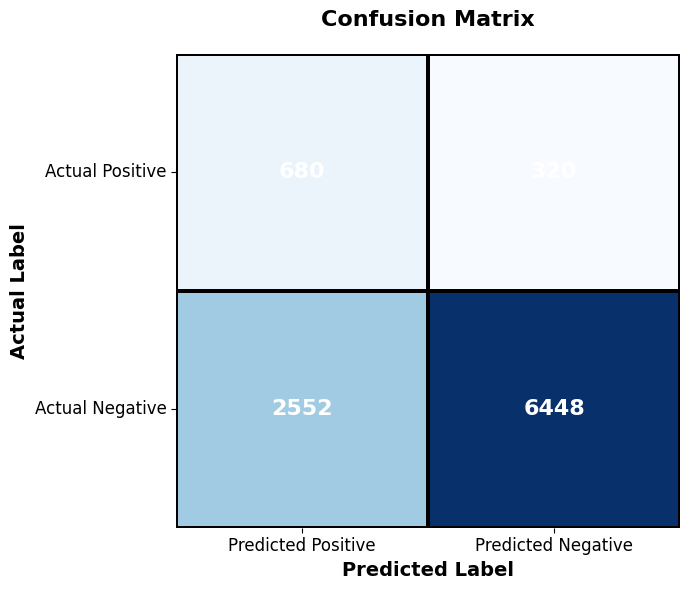

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Confusion matrix data
cm = np.array([[680, 320],
               [2552, 6448]])

# Class labels
classes = ['Positive', 'Negative']

# Plot
plt.figure(figsize=(7, 6))
ax = sns.heatmap(cm,
                 annot=True,
                 fmt='g',
                 cmap='Blues',
                 cbar=False,
                 xticklabels=[f'Predicted {label}' for label in classes],
                 yticklabels=[f'Actual {label}' for label in classes],
                 linewidths=1.5,
                 linecolor='black',
                 annot_kws={"size": 16, "weight": "bold", "color": "white"})

# Axis labels and title
plt.xlabel('Predicted Label', fontsize=14, weight='bold')
plt.ylabel('Actual Label', fontsize=14, weight='bold')
plt.title('Confusion Matrix', fontsize=16, weight='bold', pad=20)

# Tick styling
plt.xticks(rotation=0, fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show()


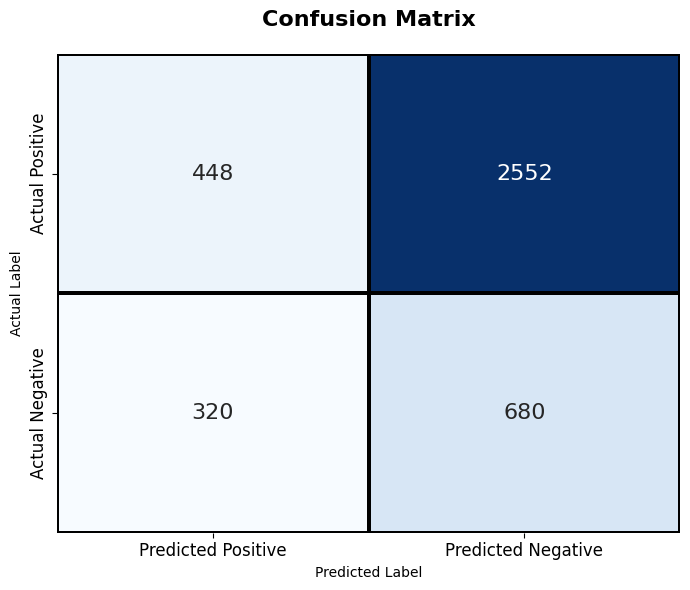

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Example true and predicted labels
# (Replace these with your actual values)
y_true = [1]*1000 + [0]*3000   # 1000 positives, 3000 negatives
y_pred = [1]*680 + [0]*320 + [1]*2552 + [0]*448  # Corresponds to CM: [[680, 320], [2552, 6448]]

# Convert to numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(7, 6))
sns.heatmap(cm,
            annot=True,
            fmt='g',
            cmap='Blues',
            cbar=False,
            xticklabels=['Predicted Positive', 'Predicted Negative'],
            yticklabels=['Actual Positive', 'Actual Negative'],
            linewidths=1.5,
            linecolor='black',
            annot_kws={"size": 16, })

# Labels
plt.xlabel('Predicted Label', )
plt.ylabel('Actual Label', )
plt.title('Confusion Matrix', fontsize=16, weight='bold', pad=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()
